In [1]:
print(123)

123


In [1]:
import pandas as pd
import numpy as np

In [2]:
df_orig = pd.read_csv("data.csv")
df_orig.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [3]:
df_orig.info()
df = df_orig

<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  str    
 1   Model              11914 non-null  str    
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  str    
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  str    
 7   Driven_Wheels      11914 non-null  str    
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   str    
 10  Vehicle Size       11914 non-null  str    
 11  Vehicle Style      11914 non-null  str    
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

### DATA PREPARATION #####

In [4]:
# change the coulumn names to all lower case and replace space with an underscore 
df = df_orig
print(df.columns)
df.columns = df.columns.str.lower().str.replace(' ', '_')
print(df.columns)



Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')
Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')


In [5]:
## change the coulumn values to all lower case and replace space with an underscore 
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['make',
 'model',
 'engine_fuel_type',
 'transmission_type',
 'driven_wheels',
 'market_category',
 'vehicle_size',
 'vehicle_style']

In [6]:
for col in strings:
    df[col] = df[col].str.lower().str.replace(' ', '_')

print(df.head())

  make       model  year             engine_fuel_type  engine_hp  \
0  bmw  1_series_m  2011  premium_unleaded_(required)      335.0   
1  bmw    1_series  2011  premium_unleaded_(required)      300.0   
2  bmw    1_series  2011  premium_unleaded_(required)      300.0   
3  bmw    1_series  2011  premium_unleaded_(required)      230.0   
4  bmw    1_series  2011  premium_unleaded_(required)      230.0   

   engine_cylinders transmission_type     driven_wheels  number_of_doors  \
0               6.0            manual  rear_wheel_drive              2.0   
1               6.0            manual  rear_wheel_drive              2.0   
2               6.0            manual  rear_wheel_drive              2.0   
3               6.0            manual  rear_wheel_drive              2.0   
4               6.0            manual  rear_wheel_drive              2.0   

                         market_category vehicle_size vehicle_style  \
0  factory_tuner,luxury,high-performance      compact         c

### EDA ###

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               11914 non-null  str    
 1   model              11914 non-null  str    
 2   year               11914 non-null  int64  
 3   engine_fuel_type   11911 non-null  str    
 4   engine_hp          11845 non-null  float64
 5   engine_cylinders   11884 non-null  float64
 6   transmission_type  11914 non-null  str    
 7   driven_wheels      11914 non-null  str    
 8   number_of_doors    11908 non-null  float64
 9   market_category    8172 non-null   str    
 10  vehicle_size       11914 non-null  str    
 11  vehicle_style      11914 non-null  str    
 12  highway_mpg        11914 non-null  int64  
 13  city_mpg           11914 non-null  int64  
 14  popularity         11914 non-null  int64  
 15  msrp               11914 non-null  int64  
dtypes: float64(3), int64(5), str(8)
m

In [8]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

df[df['market_category'].isna()].head()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
87,nissan,200sx,1996,regular_unleaded,115.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,36,26,2009,2000
88,nissan,200sx,1996,regular_unleaded,115.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,36,26,2009,2000
91,nissan,200sx,1997,regular_unleaded,115.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,35,25,2009,2000
92,nissan,200sx,1997,regular_unleaded,115.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,35,25,2009,2000
93,nissan,200sx,1998,regular_unleaded,115.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,35,25,2009,2000


           make model  year                engine_fuel_type  engine_hp  \
294     ferrari   360  2002     premium_unleaded_(required)      400.0   
295     ferrari   360  2002     premium_unleaded_(required)      400.0   
296     ferrari   360  2002     premium_unleaded_(required)      400.0   
297     ferrari   360  2002     premium_unleaded_(required)      400.0   
298     ferrari   360  2003     premium_unleaded_(required)      400.0   
...         ...   ...   ...                             ...        ...   
11736  cadillac   xlr  2008                regular_unleaded      320.0   
11737  cadillac   xlr  2009  premium_unleaded_(recommended)      320.0   
11903       bmw    z8  2001     premium_unleaded_(required)      394.0   
11904       bmw    z8  2002     premium_unleaded_(required)      394.0   
11905       bmw    z8  2003     premium_unleaded_(required)      394.0   

       engine_cylinders transmission_type     driven_wheels  number_of_doors  \
294                 8.0        

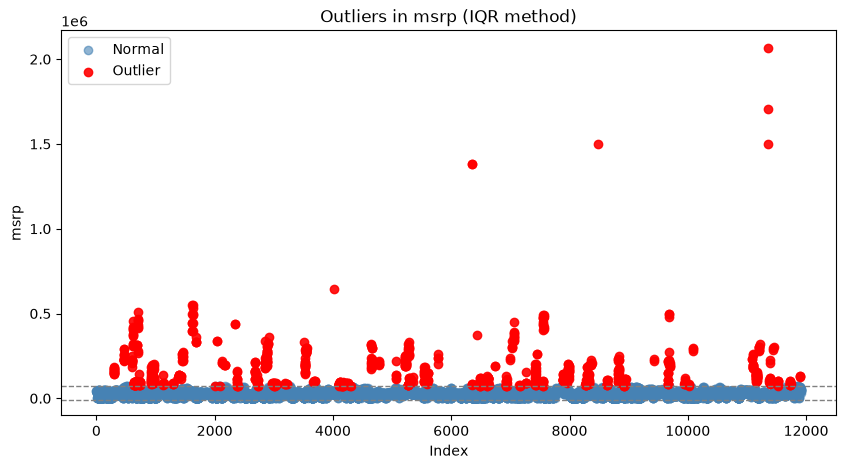

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

col = 'msrp'

Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
normal = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(outliers)  # inspect the actual outlier rows

plt.figure(figsize=(10, 5))
plt.scatter(normal.index, normal[col], color='steelblue', label='Normal', alpha=0.6)
plt.scatter(outliers.index, outliers[col], color='red', label='Outlier', alpha=0.9)
plt.axhline(upper_bound, color='gray', linestyle='--', linewidth=1)
plt.axhline(lower_bound, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Index')
plt.ylabel(col)
plt.legend()
plt.title(f'Outliers in {col} (IQR method)')
plt.show()

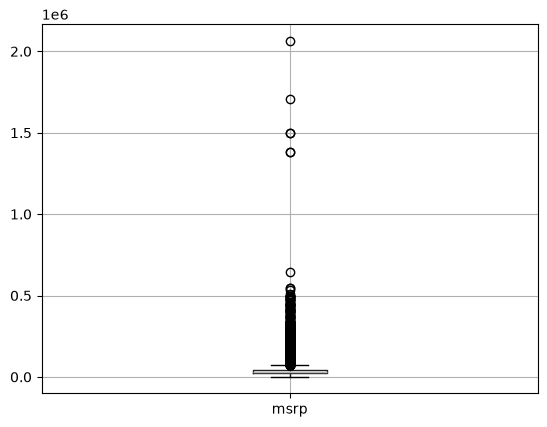

In [10]:
import matplotlib.pyplot as plt

df.boxplot(column='msrp')
plt.show()

In [11]:
Q1 = df['msrp'].quantile(0.25)
Q3 = df['msrp'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound)
print(upper_bound)

print(df[df['msrp'] <= 0].head())
df_clean = df[(df['msrp'] >= lower_bound) & (df['msrp'] <= upper_bound)]

df_clean.info()

-10846.875
74078.125
Empty DataFrame
Columns: [make, model, year, engine_fuel_type, engine_hp, engine_cylinders, transmission_type, driven_wheels, number_of_doors, market_category, vehicle_size, vehicle_style, highway_mpg, city_mpg, popularity, msrp]
Index: []
<class 'pandas.DataFrame'>
Index: 10918 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               10918 non-null  str    
 1   model              10918 non-null  str    
 2   year               10918 non-null  int64  
 3   engine_fuel_type   10915 non-null  str    
 4   engine_hp          10862 non-null  float64
 5   engine_cylinders   10888 non-null  float64
 6   transmission_type  10918 non-null  str    
 7   driven_wheels      10918 non-null  str    
 8   number_of_doors    10916 non-null  float64
 9   market_category    7176 non-null   str    
 10  vehicle_size       10918 non-null  str    
 11  vehicle_style    

In [12]:
df_clean[df_clean['market_category'].isna()]['make'].unique()
#print(df_clean['market_category'].value_counts())

print(df_clean[df_clean['market_category'].isna()]['msrp'])


87        2000
88        2000
91        2000
92        2000
93        2000
         ...  
11794     2000
11809    15950
11810    17050
11867    64520
11868    67520
Name: msrp, Length: 3742, dtype: int64


##### DATA SPLITTING of TRAINING VALIDATION and TESTING data #####

In [13]:
from sklearn.model_selection import train_test_split 

train_val_df, test_df = train_test_split(df_clean, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.176, random_state=42)

#print("train_df")
#print(train_df.head())
#print("val_df")
#print(val_df.head())
#print("test_df")
#print(test_df.head())

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# exrtacting the target values that need to be predicted by the model
y_train = train_df.msrp.values
y_val = val_df.msrp.values
y_test = test_df.msrp.values

# removing the predicted values from training X data 
train_df.drop(columns=['msrp'],inplace=True)
val_df.drop(columns=['msrp'],inplace=True)
test_df.drop(columns=['msrp'],inplace=True)

print(train_df.info())
print(val_df.info())
print(test_df.info())




<class 'pandas.DataFrame'>
RangeIndex: 7646 entries, 0 to 7645
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               7646 non-null   str    
 1   model              7646 non-null   str    
 2   year               7646 non-null   int64  
 3   engine_fuel_type   7644 non-null   str    
 4   engine_hp          7611 non-null   float64
 5   engine_cylinders   7622 non-null   float64
 6   transmission_type  7646 non-null   str    
 7   driven_wheels      7646 non-null   str    
 8   number_of_doors    7645 non-null   float64
 9   market_category    5055 non-null   str    
 10  vehicle_size       7646 non-null   str    
 11  vehicle_style      7646 non-null   str    
 12  highway_mpg        7646 non-null   int64  
 13  city_mpg           7646 non-null   int64  
 14  popularity         7646 non-null   int64  
dtypes: float64(3), int64(4), str(8)
memory usage: 896.1 KB
None
<class 'pandas.DataFram

In [14]:
#removing unncessaru attributes that dont impact the price of the car
train_df.drop(columns=['market_category'],inplace=True)
val_df.drop(columns=['market_category'],inplace=True)
test_df.drop(columns=['market_category'],inplace=True)

In [15]:
print(train_df.info())
print(val_df.info())
print(test_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7646 entries, 0 to 7645
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               7646 non-null   str    
 1   model              7646 non-null   str    
 2   year               7646 non-null   int64  
 3   engine_fuel_type   7644 non-null   str    
 4   engine_hp          7611 non-null   float64
 5   engine_cylinders   7622 non-null   float64
 6   transmission_type  7646 non-null   str    
 7   driven_wheels      7646 non-null   str    
 8   number_of_doors    7645 non-null   float64
 9   vehicle_size       7646 non-null   str    
 10  vehicle_style      7646 non-null   str    
 11  highway_mpg        7646 non-null   int64  
 12  city_mpg           7646 non-null   int64  
 13  popularity         7646 non-null   int64  
dtypes: float64(3), int64(4), str(7)
memory usage: 836.4 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 1634 entries, 0 to 1633
Data col

In [17]:
#default missing valiues
train_df['engine_hp'] = train_df['engine_hp'].fillna(train_df['engine_hp'].median())
train_df['engine_cylinders'] = train_df['engine_cylinders'].fillna(train_df['engine_cylinders'].median())
train_df['number_of_doors'] = train_df['number_of_doors'].fillna(train_df['number_of_doors'].median())
train_df['transmission_type'] = train_df['transmission_type'].fillna(train_df['transmission_type'].mode())


val_df['engine_hp'] = val_df['engine_hp'].fillna(val_df['engine_hp'].median())
val_df['engine_cylinders'] = val_df['engine_cylinders'].fillna(val_df['engine_cylinders'].median())
val_df['number_of_doors'] = val_df['number_of_doors'].fillna(val_df['number_of_doors'].median())


test_df['engine_hp'] = test_df['engine_hp'].fillna(test_df['engine_hp'].median())
test_df['engine_cylinders'] = test_df['engine_cylinders'].fillna(test_df['engine_cylinders'].median())
test_df['number_of_doors'] = test_df['number_of_doors'].fillna(test_df['number_of_doors'].median())


In [18]:
print(train_df.info())
print(val_df.info())
print(test_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7646 entries, 0 to 7645
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               7646 non-null   str    
 1   model              7646 non-null   str    
 2   year               7646 non-null   int64  
 3   engine_fuel_type   7644 non-null   str    
 4   engine_hp          7646 non-null   float64
 5   engine_cylinders   7646 non-null   float64
 6   transmission_type  7646 non-null   str    
 7   driven_wheels      7646 non-null   str    
 8   number_of_doors    7646 non-null   float64
 9   vehicle_size       7646 non-null   str    
 10  vehicle_style      7646 non-null   str    
 11  highway_mpg        7646 non-null   int64  
 12  city_mpg           7646 non-null   int64  
 13  popularity         7646 non-null   int64  
dtypes: float64(3), int64(4), str(7)
memory usage: 836.4 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 1634 entries, 0 to 1633
Data col

In [19]:
train_df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,acura,integra,2000,regular_unleaded,140.0,4.0,manual,front_wheel_drive,2.0,compact,2dr_hatchback,28,22,204
1,subaru,b9_tribeca,2006,premium_unleaded_(required),250.0,6.0,automatic,all_wheel_drive,4.0,midsize,4dr_suv,21,16,640
2,cadillac,cts_coupe,2013,regular_unleaded,318.0,6.0,automatic,all_wheel_drive,2.0,midsize,coupe,27,18,1624
3,kia,spectra,2009,regular_unleaded,138.0,4.0,manual,front_wheel_drive,4.0,compact,sedan,30,23,1720
4,cadillac,xt5,2017,premium_unleaded_(required),310.0,6.0,automatic,all_wheel_drive,4.0,midsize,4dr_suv,26,18,1624


In [20]:
#print(train_df['engine_fuel_type'].value_counts())
#print(train_df['vehicle_size'].value_counts())
#print(train_df['transmission_type'].value_counts())
#print(train_df['driven_wheels'].value_counts())
#print(train_df['vehicle_size'].value_counts())
print(train_df['vehicle_style'].value_counts())

vehicle_style
sedan                  1993
4dr_suv                1587
coupe                   617
4dr_hatchback           512
crew_cab_pickup         469
extended_cab_pickup     417
wagon                   414
convertible             393
2dr_hatchback           367
passenger_minivan       284
regular_cab_pickup      268
passenger_van            98
2dr_suv                  93
cargo_van                63
cargo_minivan            50
convertible_suv          21
Name: count, dtype: int64


In [21]:
X_train = pd.get_dummies(train_df, columns=['transmission_type', 'driven_wheels', 'vehicle_size', 
                                          'engine_fuel_type', 'vehicle_style'], drop_first=True)

X_val = pd.get_dummies(val_df, columns=['transmission_type', 'driven_wheels', 'vehicle_size', 
                                          'engine_fuel_type', 'vehicle_style'], drop_first=True)

X_test = pd.get_dummies(test_df, columns=['transmission_type', 'driven_wheels', 'vehicle_size', 
                                          'engine_fuel_type', 'vehicle_style'], drop_first=True)
print(X_train.info())
print(X_val.info())
print(X_test.info())

<class 'pandas.DataFrame'>
RangeIndex: 7646 entries, 0 to 7645
Data columns (total 42 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   make                                                           7646 non-null   str    
 1   model                                                          7646 non-null   str    
 2   year                                                           7646 non-null   int64  
 3   engine_hp                                                      7646 non-null   float64
 4   engine_cylinders                                               7646 non-null   float64
 5   number_of_doors                                                7646 non-null   float64
 6   highway_mpg                                                    7646 non-null   int64  
 7   city_mpg                                                       7646 non

In [22]:
X_train.iloc[10]

make                                                             toyota
model                                                            tundra
year                                                               2015
engine_hp                                                         310.0
engine_cylinders                                                    8.0
number_of_doors                                                     4.0
highway_mpg                                                          19
city_mpg                                                             15
popularity                                                         2031
transmission_type_automatic                                        True
transmission_type_direct_drive                                    False
transmission_type_manual                                          False
transmission_type_unknown                                         False
driven_wheels_four_wheel_drive                                  

In [23]:
y_train[10]

np.int64(32480)

In [24]:
##### going back to techniques explained in the lessons #####

xi = [310,15,2031] #engine_hp,city_mpg,popularity

In [25]:
w0 = 0
w = [1,1,1]

In [26]:
#def lenear_regression(xi):
#    pred = w0
#    n = len(xi)
#    for j in range(n):
#        pred = pred + w[j] * xi[j]

#    return pred
def dot(xi,w):
    n = len(xi)
    res = 0.0
    for j in range(n):
        res = res + xi[j] * w[j]
    return res    

def lenear_regression(xi):
    return w0 + dot(xi,w)

In [27]:
print(lenear_regression(xi))

2356.0


In [28]:
w0 = 7.17
w = [0.01,0.04,0.02]
print(lenear_regression(xi))

51.49


In [29]:
w_new = [w0]+ w
def lenear_regression(xi):
    xi = [1] + xi
    return dot(xi,w_new)

print(lenear_regression(xi))

51.489999999999995


In [30]:
w_new

[7.17, 0.01, 0.04, 0.02]

In [31]:
x1 = [1,148,24,1385]
x2 = [1,132,25,2031]
x10 = [1,453,11,86]

X = [x1,x2,x10]
X = np.array(X)

In [32]:
w_new

[7.17, 0.01, 0.04, 0.02]

In [33]:
X.dot(w_new)

array([37.31, 50.11, 13.86])

In [34]:
### WEIGHTS derivation 
X = [
    [148,24,1385],
    [34,56,79],
    [341,556,8979],
    [168,24,1385],
    [354,56,79],
    [31,556,8979],
    [14,24,1385],
    [44,56,79],
    [334,556,8979]    
    ]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [  34,   56,   79],
       [ 341,  556, 8979],
       [ 168,   24, 1385],
       [ 354,   56,   79],
       [  31,  556, 8979],
       [  14,   24, 1385],
       [  44,   56,   79],
       [ 334,  556, 8979]])

In [35]:
y = [100,200,500,150,250,550,200,300,600]

In [36]:
ones  = np.ones(X.shape[0])


In [37]:
X = np.column_stack([ones,X])

In [38]:
XTX = X.T.dot(X)
XTX

array([[9.00000000e+00, 1.46800000e+03, 1.90800000e+03, 3.13290000e+04],
       [1.46800000e+03, 4.07530000e+05, 4.24648000e+05, 6.83035200e+06],
       [1.90800000e+03, 4.24648000e+05, 9.38544000e+05, 1.50899640e+07],
       [3.13290000e+04, 6.83035200e+06, 1.50899640e+07, 2.47640721e+08]])

In [39]:
XTX_inv = np.linalg.inv(XTX)
XTX_inv

array([[ 2.99325347e-01, -8.39840098e-04,  3.88551054e-04,
        -3.83797208e-05],
       [-8.39840098e-04,  6.99904346e-06, -3.14860929e-06,
         1.05062772e-07],
       [ 3.88551054e-04, -3.14860929e-06,  5.39422645e-05,
        -3.24927836e-06],
       [-3.83797208e-05,  1.05062772e-07, -3.24927836e-06,
         2.03990183e-07]])

In [40]:
print(XTX.dot(XTX_inv).round(1)) 

[[ 1.  0. -0.  0.]
 [-0.  1.  0. -0.]
 [-0. -0.  1.  0.]
 [-0.  0.  0.  1.]]


In [41]:
w_full = XTX_inv.dot(X.T).dot(y)
w_full

array([ 1.82362544e+02, -4.58437347e-02,  1.38743934e+00, -4.37677090e-02])

In [ ]:
def train_linear_regression(X,y):
    ones  = np.ones(X.shape[0])
    X = np.column_stack([ones,X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0],w_full[1:]

In [65]:
print(train_linear_regression(X,y))

(np.float64(91.18127179878849), array([ 9.11812718e+01, -4.58437347e-02,  1.38743934e+00, -4.37677090e-02]))


In [44]:
############ BASE LINE REGRESSION MODEL ###########
train_df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'vehicle_size', 'vehicle_style', 'highway_mpg',
       'city_mpg', 'popularity'],
      dtype='str')

In [46]:
base = ['engine_hp','engine_cylinders','highway_mpg','city_mpg','popularity']

X_train = train_df[base].values



In [47]:
print(X_train)
print(y_train)

[[ 140.    4.   28.   22.  204.]
 [ 250.    6.   21.   16.  640.]
 [ 318.    6.   27.   18. 1624.]
 ...
 [ 278.    6.   30.   20. 2202.]
 [ 116.    4.   23.   18.  436.]
 [ 280.    6.   29.   20.  204.]]
[ 3130 32395 40805 ... 33690  2000 41960]


In [48]:
w0, w = train_linear_regression(X_train,y_train)

In [49]:
y_pred = w0 + X_train.dot(w)
y_pred

array([16686.30745294, 29516.18017128, 43586.56254606, ...,
       36516.7258426 , 10895.87426877, 37152.27590938], shape=(7646,))

<Axes: ylabel='Count'>

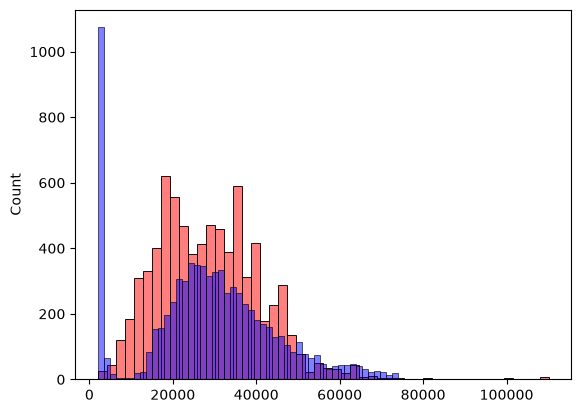

In [50]:
import seaborn as sns
from matplotlib import pyplot as plt
sns.histplot(y_pred,color='red',alpha=0.5, bins=50)
sns.histplot(y_train,color='blue',alpha=0.5, bins=50)

In [51]:
######## RMSE (Root mean squarred ERROR ##########)
def rmse(y,y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [52]:
print(rmse(y_train,y_pred))

9840.035254643222


In [53]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [54]:
X_train = prepare_X(train_df)
w0, w = train_linear_regression(X_train,y_train)

X_val = prepare_X(val_df)
w0, w = train_linear_regression(X_val,y_val)
y_pred = w0 + X_val.dot(w)

print(rmse(y_val,y_pred))

9231.022925661671


In [55]:
train_df['year'].max() - train_df['year']

0       17
1       11
2        4
3        8
4        0
        ..
7641    22
7642     1
7643     3
7644    23
7645     3
Name: year, Length: 7646, dtype: int64

In [56]:
def prepare_X(df):
    df = df.copy()
    max_age = df['year'].max()
    df['age'] = max_age - df['year']
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

8057.077646338009


<Axes: ylabel='Count'>

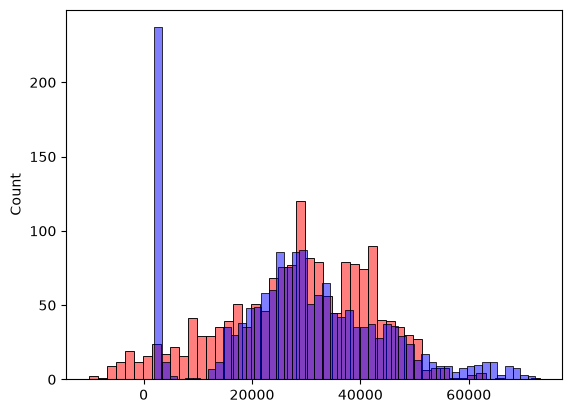

In [57]:
X_train = prepare_X(train_df)
w0, w = train_linear_regression(X_train,y_train)

X_val = prepare_X(val_df)
y_pred = w0 + X_val.dot(w)

print(rmse(y_val,y_pred))
sns.histplot(y_pred,color='red',alpha=0.5, bins=50)
sns.histplot(y_val,color='blue',alpha=0.5, bins=50)

In [ ]:
################ CATEGORICAL VARIABLES ###############
train_df.head()

for v in [2,3,4]:
    train_df['num_doors_%s' % v] = (train_df.number_of_doors == v).astype('int')

train_df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,num_doors_2,num_doors_3,num_doors_4
0,acura,integra,2000,regular_unleaded,140.0,4.0,manual,front_wheel_drive,2.0,compact,2dr_hatchback,28,22,204,1,0,0
1,subaru,b9_tribeca,2006,premium_unleaded_(required),250.0,6.0,automatic,all_wheel_drive,4.0,midsize,4dr_suv,21,16,640,0,0,1
2,cadillac,cts_coupe,2013,regular_unleaded,318.0,6.0,automatic,all_wheel_drive,2.0,midsize,coupe,27,18,1624,1,0,0
3,kia,spectra,2009,regular_unleaded,138.0,4.0,manual,front_wheel_drive,4.0,compact,sedan,30,23,1720,0,0,1
4,cadillac,xt5,2017,premium_unleaded_(required),310.0,6.0,automatic,all_wheel_drive,4.0,midsize,4dr_suv,26,18,1624,0,0,1


In [58]:
def prepare_X(df):
    df = df.copy()
    max_age = df['year'].max()
    features = base.copy()

    df['age'] = max_age - df['year']
    features.append('age')


    for v in [2,3,4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [ ]:
prepare_X(train_df)

array([[140.,   4.,  28., ...,   1.,   0.,   0.],
       [250.,   6.,  21., ...,   0.,   0.,   1.],
       [318.,   6.,  27., ...,   1.,   0.,   0.],
       ...,
       [278.,   6.,  30., ...,   0.,   0.,   1.],
       [116.,   4.,  23., ...,   1.,   0.,   0.],
       [280.,   6.,  29., ...,   0.,   0.,   1.]], shape=(7646, 9))

21536.456346545972


<Axes: ylabel='Count'>

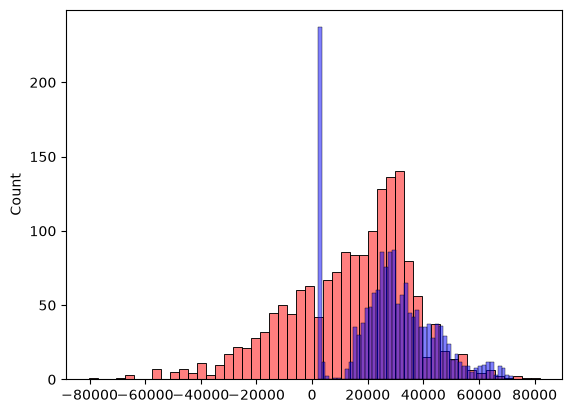

In [59]:

X_train = prepare_X(train_df)
w0, w = train_linear_regression(X_train,y_train)

X_val = prepare_X(val_df)
y_pred = w0 + X_val.dot(w)

print(rmse(y_val,y_pred))
sns.histplot(y_pred,color='red',alpha=0.5, bins=50)
sns.histplot(y_val,color='blue',alpha=0.5, bins=50)

In [60]:

# makes = list(df['makes'].)

makes = list(df['make'].value_counts().index)
makes

['chevrolet',
 'ford',
 'volkswagen',
 'toyota',
 'dodge',
 'nissan',
 'gmc',
 'honda',
 'mazda',
 'cadillac',
 'mercedes-benz',
 'suzuki',
 'bmw',
 'infiniti',
 'audi',
 'hyundai',
 'volvo',
 'subaru',
 'acura',
 'kia',
 'mitsubishi',
 'lexus',
 'buick',
 'chrysler',
 'pontiac',
 'lincoln',
 'oldsmobile',
 'land_rover',
 'porsche',
 'saab',
 'aston_martin',
 'plymouth',
 'bentley',
 'ferrari',
 'fiat',
 'scion',
 'maserati',
 'lamborghini',
 'rolls-royce',
 'lotus',
 'tesla',
 'hummer',
 'maybach',
 'alfa_romeo',
 'mclaren',
 'spyker',
 'genesis',
 'bugatti']

In [61]:
def prepare_X(df):
    df = df.copy()
    max_age = df['year'].max()
    features = base.copy()

    df['age'] = max_age - df['year']
    features.append('age')


    for v in [2,3,4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for v in makes:
        df['make_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('make_%s' % v)

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [62]:
train_df.info()
val_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7646 entries, 0 to 7645
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               7646 non-null   str    
 1   model              7646 non-null   str    
 2   year               7646 non-null   int64  
 3   engine_fuel_type   7644 non-null   str    
 4   engine_hp          7646 non-null   float64
 5   engine_cylinders   7646 non-null   float64
 6   transmission_type  7646 non-null   str    
 7   driven_wheels      7646 non-null   str    
 8   number_of_doors    7646 non-null   float64
 9   vehicle_size       7646 non-null   str    
 10  vehicle_style      7646 non-null   str    
 11  highway_mpg        7646 non-null   int64  
 12  city_mpg           7646 non-null   int64  
 13  popularity         7646 non-null   int64  
dtypes: float64(3), int64(4), str(7)
memory usage: 836.4 KB
<class 'pandas.DataFrame'>
RangeIndex: 1634 entries, 0 to 1633
Data columns 

8050.0356138397865


<Axes: ylabel='Count'>

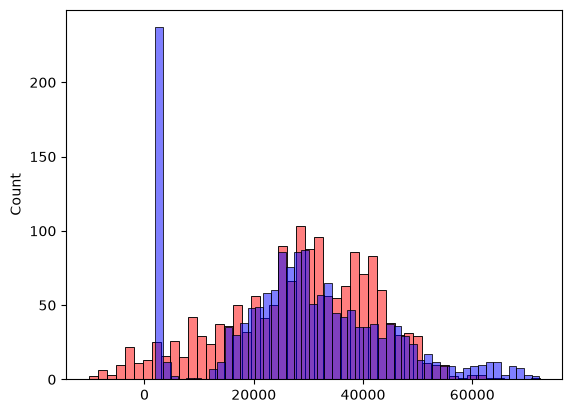

In [66]:
X_train = prepare_X(train_df)
w0, w = train_linear_regression(X_train,y_train)

X_val = prepare_X(val_df)
y_pred = w0 + X_val.dot(w)

print(rmse(y_val,y_pred))
sns.histplot(y_pred,color='red',alpha=0.5, bins=50)
sns.histplot(y_val,color='blue',alpha=0.5, bins=50)

In [67]:
X_train

array([[140.,   4.,  28., ...,   0.,   0.,   0.],
       [250.,   6.,  21., ...,   0.,   0.,   0.],
       [318.,   6.,  27., ...,   0.,   0.,   0.],
       ...,
       [278.,   6.,  30., ...,   0.,   0.,   0.],
       [116.,   4.,  23., ...,   0.,   0.,   0.],
       [280.,   6.,  29., ...,   0.,   0.,   0.]], shape=(7646, 57))

In [68]:
train_df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'vehicle_size', 'vehicle_style', 'highway_mpg',
       'city_mpg', 'popularity'],
      dtype='str')

In [72]:


categorical_variables = [
    'make','engine_fuel_type','transmission_type','driven_wheels','vehicle_size','vehicle_style'
]
categories = {}
for c in categorical_variables:
    categories[c] = list(df[c].value_counts().index)

categories

{'make': ['chevrolet',
  'ford',
  'volkswagen',
  'toyota',
  'dodge',
  'nissan',
  'gmc',
  'honda',
  'mazda',
  'cadillac',
  'mercedes-benz',
  'suzuki',
  'bmw',
  'infiniti',
  'audi',
  'hyundai',
  'volvo',
  'subaru',
  'acura',
  'kia',
  'mitsubishi',
  'lexus',
  'buick',
  'chrysler',
  'pontiac',
  'lincoln',
  'oldsmobile',
  'land_rover',
  'porsche',
  'saab',
  'aston_martin',
  'plymouth',
  'bentley',
  'ferrari',
  'fiat',
  'scion',
  'maserati',
  'lamborghini',
  'rolls-royce',
  'lotus',
  'tesla',
  'hummer',
  'maybach',
  'alfa_romeo',
  'mclaren',
  'spyker',
  'genesis',
  'bugatti'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel',
  'electric',
  'flex-fuel_(premium_unleaded_required/e85)',
  'flex-fuel_(premium_unleaded_recommended/e85)',
  'flex-fuel_(unleaded/natural_gas)',
  'natural_gas'],
 'transmission_type': ['automatic',
  'manual',
  'autom

In [74]:
def prepare_X(df):
    df = df.copy()
    max_age = df['year'].max()
    features = base.copy()

    df['age'] = max_age - df['year']
    features.append('age')


    for v in [2,3,4]:
        df['num_doors_%s' % v] = (df.number_of_doors == v).astype('int')
        features.append('num_doors_%s' % v)

    for c, values in categories.items():
        for v in values:
            df['%s_%s' % (c, v)] = (df[c] == v).astype('int')
            features.append('%s_%s' % (c,v))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

6193.701064914179


<Axes: ylabel='Count'>

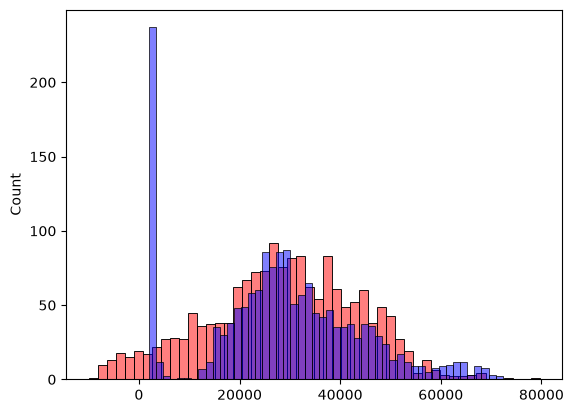

In [75]:
X_train = prepare_X(train_df)
w0, w = train_linear_regression(X_train,y_train)

X_val = prepare_X(val_df)
y_pred = w0 + X_val.dot(w)

print(rmse(y_val,y_pred))
sns.histplot(y_pred,color='red',alpha=0.5, bins=50)
sns.histplot(y_val,color='blue',alpha=0.5, bins=50)

In [ ]:
 ###### REGULARIZATION #######
